In [1]:
# python
from concurrent.futures import ThreadPoolExecutor
from typing import Sequence
import time
import pickle
import os
import glob

# ESM
from esm.sdk.forge import ESM3ForgeInferenceClient
from esm.sdk.api import ESMProtein, LogitsConfig, ESMProteinError
from esm.sdk import batch_executor, client

from esm.models.esmc import ESMC

from esm.sdk.api import (
    ESM3InferenceClient,
    ESMProtein,
    ESMProteinError,
    LogitsConfig,
    LogitsOutput,
    ProteinType,
)

# other NN utils
import torch

# biopython
from Bio import SeqIO

# sklearn
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score

# other utils
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import adjusted_rand_score



# Functions

In [2]:
# functions for embedding ESM proteins

EMBEDDING_CONFIG = LogitsConfig(
    sequence=True, return_embeddings=True, return_hidden_states=True
)

def embed_sequence(model: ESM3InferenceClient, sequence: str) -> LogitsOutput:
    protein = ESMProtein(sequence=sequence)
    protein_tensor = model.encode(protein)
    output = model.logits(protein_tensor, EMBEDDING_CONFIG)
    return output


def batch_embed(
    model: ESM3InferenceClient, inputs: Sequence[ProteinType]
) -> Sequence[LogitsOutput]:
    """Forge supports auto-batching. So batch_embed() is as simple as running a collection
    of embed calls in parallel using asyncio.
    """
    with ThreadPoolExecutor() as executor:
        futures = [
            executor.submit(embed_sequence, model, protein) for protein in inputs
        ]
        results = []
        for future in futures:
            try:
                results.append(future.result())
            except Exception as e:
                results.append(ESMProteinError(500, str(e)))
    return results
     
esmc_model = ESMC.from_pretrained("esmc_300m") #.to("cuda") # or "cpu"

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

In [3]:
with open('./../data/20240122_all_adks_filtered.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]
    seqs = [str(r.seq) for r in records]
    names = [str(r.id) for r in records]

In [4]:
# # %%time
# batches = np.linspace(0, len(seqs)+1, 200).astype(int)
# for i, b in enumerate(batches[:-1]):
#     _seqs, _names = seqs[batches[i]:batches[i+1]], names[batches[i]:batches[i+1]]
    
#     while len(_seqs) > 0:
#         full_run = len(_seqs)
#         print(f'Running for {full_run} seqs')
#         outputs = dict((n, o) for n,o in zip(_names, batch_embed(esmc_model, _seqs)))
#         completed = set([k for k in outputs.keys() if not isinstance(outputs[k], ESMProteinError)])
#         print(f'{len(completed)} of {len(_seqs)} completed')
#         _seqs, _names = [_seqs[i] for i in range(len(_seqs)) if not _names[i] in completed], [_names[i] for i in range(len(_names)) if not _names[i] in completed]
#         assert len(_seqs) == len(_names)

#     with open(f'./../data/esmc/batches/batch_{i}.pkl', 'wb') as handle:
#         pickle.dump(outputs, handle)

In [23]:
def load_mean_embeddings(path):
    all_mean_embeddings = {}
    
    batches = glob.glob(os.path.join(path, '*.pkl'))
    for batch in batches:
        with open(batch, 'rb') as handle:
            protein_data = pickle.load(handle)
            
        batch_mean_embeddings = dict(
            (p, torch.mean(protein_data[p].hidden_states, dim=-2).squeeze()) for p in protein_data.keys() if not isinstance(protein_data[p], ESMProteinError, )
        )

        all_mean_embeddings.update(batch_mean_embeddings)

    return all_mean_embeddings

def get_layer_df(layer_idx, embeddings):
    return pd.DataFrame(torch.stack(
                                [embeddings[p][layer_idx, :] for p in embeddings.keys()]
                                ).numpy(),
                    index=list(embeddings.keys()))

In [6]:

%%time
# we'll summarize the embeddings using their mean across the sequence dimension
# which allows us to compare embeddings for sequences of different lengths
all_mean_embeddings = load_mean_embeddings('./../data/esmc/batches/')

# now we have a list of tensors of [num_layers, hidden_size]
# print("embedding shape [num_layers, hidden_size]:", all_mean_embeddings[0].shape)

CPU times: user 2min 40s, sys: 55.5 s, total: 3min 35s
Wall time: 1min 32s


In [7]:
filtered = pd.read_csv('/data/mhoffert/fiererlab/adenylate_kinase_ogt/data/metric_tables/20240327_metrics_df_filtered.tsv.gz', sep='\t')

# Initial PCA

In [97]:
import itertools

In [236]:
layer_idx = 29
stacked_mean_embeddings = pd.DataFrame(torch.stack(
    [all_mean_embeddings[p][layer_idx, :] for p in all_mean_embeddings.keys()]
).numpy(),
    index=list(all_mean_embeddings.keys()))

# project all the embeddings to 2D using PCA
N_COMP=50
pca = PCA(n_components=N_COMP)
pca.fit(stacked_mean_embeddings)
projected_mean_embeddings = pca.transform(stacked_mean_embeddings)

plotdf = pd.merge(pd.DataFrame(projected_mean_embeddings, index=stacked_mean_embeddings.index),
                  pd.Series(dict((s,float(s.split('|')[3].replace('temp=',''))) for s in stacked_mean_embeddings.index)).rename('temp'),
                  left_index=True, right_index=True)

plotdf.index = [i.split('|')[1] for i in plotdf.index]




<Figure size 600x600 with 0 Axes>

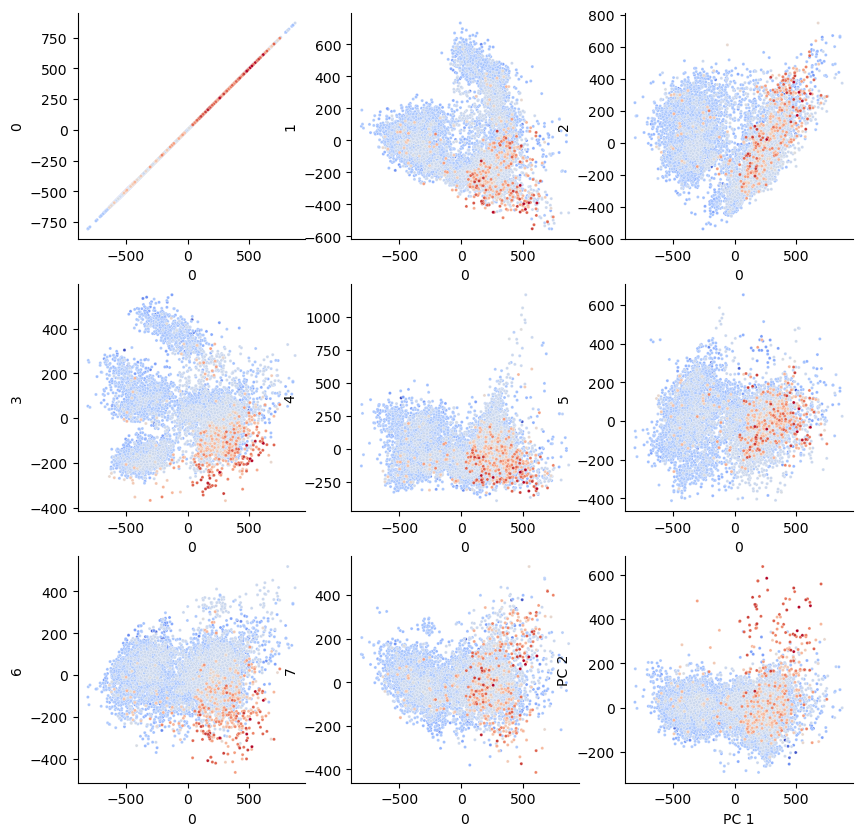

In [239]:
# plot the clusters
plt.figure(figsize=(6, 6))
fig = plt.figure(figsize=(10, 10))
i = 1
for col1, col2 in itertools.product(plotdf.drop('temp', axis=1).columns, 
                                    plotdf.drop('temp', axis=1).columns):
    ax = fig.add_subplot(3,3,i)
    sns.scatterplot(
        data=plotdf.sort_values('temp'),
        x=col1,
        y=col2,
        hue='temp',
        palette='coolwarm',
        s=5
    )
    i += 1
    ax.get_legend().remove()
    sns.despine()

    if i > 9:
        break

# plt.title(
#     f"PCA of mean embeddings at layer {layer_idx}.\nRand index: {rand_index:.2f}"
# )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()



In [300]:
pca.explained_variance_ratio_

array([0.27373528, 0.13717876, 0.09991292, 0.07423483, 0.06148591],
      dtype=float32)

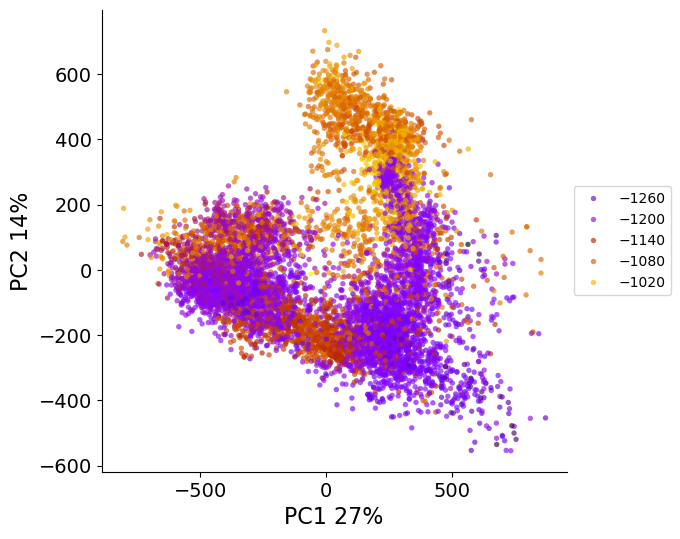

In [331]:
fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(1,1,1)
sns.scatterplot(
    data=plotdf,
    linewidth=0,
    x=0,
    y=1,
    hue=filtered.set_index('uid')['fa_atr'] ,
    # size=filtered.set_index('uid')['SASA'],
    palette='gnuplot',
    s=15, alpha=0.65
)
ax.set_xlabel(f'PC1 {pca.explained_variance_ratio_[0] * 100:.0f}%',
             fontsize=16)
ax.set_ylabel(f'PC2 {pca.explained_variance_ratio_[1] * 100:.0f}%',
             fontsize=16)
# ax.get_legend().remove()
lgd = ax.legend(loc='center left', bbox_to_anchor=(1, 0.5))
sns.despine()

plt.tick_params(labelsize=14)
plt.savefig('./../data/figures/esmc_pca_LJ.png', dpi=400, bbox_inches='tight')

In [318]:
filtered

,Unnamed: 0,Position,Contacts at 4.5 Å,SASA,uid,total_score,avg_deg_4_5,avg_deg_8,avg_sc_nbrs_res_summary,bb_internal_hbonds,...,temp,mean_temp,seq_length,bitscore,C,L,N,P,max_structure_length,lid_bitscore
0,0,94.0,11.358289,52.616491,GB_GCA_000376885.1,-454.076,1.278,10.765,2.648,124.0,...,37.0,37.00,187,178.2,90.0,48.0,42.0,6.0,24,0.0
1,1,108.0,11.125581,49.464040,GB_GCA_000016765.1,-450.126,1.316,10.730,2.697,132.0,...,30.0,30.00,215,175.3,116.0,49.0,43.0,6.0,23,52.3
2,2,119.5,11.289720,49.538232,GB_GCA_000242235.1,-419.604,1.327,10.981,2.842,128.0,...,37.0,37.00,214,192.2,117.0,48.0,42.0,6.0,24,59.2
3,3,105.5,11.276190,50.018080,GB_GCA_000283575.1,-452.738,1.390,10.905,2.771,129.0,...,30.0,30.00,210,168.7,112.0,48.0,43.0,6.0,24,58.3
4,4,91.0,11.359116,51.483049,GB_GCA_001054945.1,-431.800,1.243,10.768,2.669,117.0,...,37.0,37.00,181,192.9,88.0,44.0,42.0,6.0,21,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8527,9336,111.0,11.257919,49.134618,RS_GCF_905397275.1,-492.694,1.353,10.846,2.780,130.0,...,30.0,28.75,221,195.8,123.0,48.0,43.0,6.0,28,61.7
8528,9337,99.0,11.502591,51.214600,RS_GCF_907163105.1,-494.248,1.290,11.031,2.738,128.0,...,30.0,33.50,193,165.6,122.0,22.0,42.0,6.0,24,0.0
8529,9338,111.0,11.366516,49.484025,RS_GCF_905397435.1,-469.955,1.362,10.810,2.811,133.0,...,27.0,26.40,221,194.9,123.0,48.0,43.0,6.0,28,61.6
8530,9339,108.0,11.479070,49.243296,RS_GCF_910593845.1,-487.960,1.288,10.833,2.731,133.0,...,30.0,29.50,215,190.8,118.0,48.0,42.0,6.0,24,66.3


# Figuring out best layer to use for embedding

In [125]:
y = pd.Series(data=[float(i.split('|')[3].replace('temp=', '')) for i in stacked_mean_embeddings.index],
              index=stacked_mean_embeddings.index)

In [133]:
from IPython.display import display, clear_output

# assumes you have: embeddings[layer] -> list of np arrays (N, seq_len, D)
# and targets: ogt (N,)
import numpy as np
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error


In [134]:

layers = list(range(30))
poolings = ['mean']  # extend as needed
results = {}

kf = KFold(n_splits=5, shuffle=True, random_state=0)

for layer_idx in layers:
    print(layer_idx)
    # embeddings_layer: list of N arrays (seq_len, D)
    E = pd.DataFrame(torch.stack(
                                [all_mean_embeddings[p][layer_idx, :] for p in all_mean_embeddings.keys()]
                                ).numpy(),
                    index=list(all_mean_embeddings.keys()))
    
    #E = np.array([np.mean(e, axis=0) for e in embeddings[layer]])  # mean pooling baseline -> shape (N, D)
    # Try standardizing
    #scaler = StandardScaler()
    #X = scaler.fit_transform(E)
    X = E.copy()
    ridge = RidgeCV(alphas=np.logspace(-6,3,10), cv=3)
    r2s = []
    maes = []
    for train_idx, test_idx in kf.split(X):
        ridge.fit(X.iloc[train_idx, :], y.iloc[train_idx])
        ypred = ridge.predict(X.iloc[test_idx, :])
        r2s.append(r2_score(y.iloc[test_idx], ypred))
        maes.append(mean_absolute_error(y.iloc[test_idx], ypred))
    results[(layer_idx,'mean')] = {'r2': np.mean(r2s), 'r2_std': np.std(r2s), 'mae': np.mean(maes)}
    clear_output(wait=True)

# visualize: plot layer vs r2 for pooling 'mean'


29


/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.64399e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.57325e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.65629e-08): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T
/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:204: LinAlgWarning: Ill-conditioned matrix (rcond=1.64399e-08): result may not be

Text(0.5, 0, 'Layer ID')

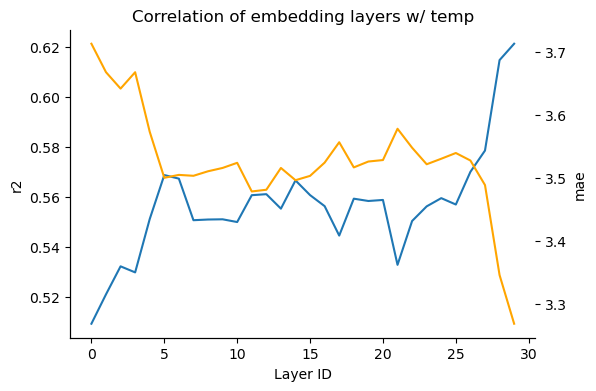

In [161]:
fig, ax = plt.subplots(figsize=(6,4))
ax2 = ax.twinx()
sns.lineplot(data=pd.DataFrame(results).T.reset_index(),
               y='r2', x='level_0', ax=ax)

sns.lineplot(data=pd.DataFrame(results).T.reset_index(),
               y='mae', x='level_0',ax=ax2, color='orange')

sns.despine()
ax.set_title('Correlation of embedding layers w/ temp')
ax.set_xlabel('Layer ID')

# Fitting model

In [8]:
import statsmodels.api as sm
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import StandardScaler
from statsmodels.nonparametric.smoothers_lowess import lowess


# function to get weights based on y variable density
def compute_gaussian_weights(_y):
    # Normalize the target variable to compute KDE
    scaler = StandardScaler()
    y_scaled = scaler.fit_transform(_y.values.reshape(-1, 1))
    
    # Estimate density of target variable using KDE
    kde = KernelDensity(kernel='gaussian', bandwidth=0.4)
    kde.fit(y_scaled)
    log_density = kde.score_samples(y_scaled)
    density = np.exp(log_density)
    
    # Compute weights as inverse of density
    weights = 1 / density

    return weights

In [9]:
layer_idx = 29
stacked_mean_embeddings = pd.DataFrame(torch.stack(
    [all_mean_embeddings[p][layer_idx, :] for p in all_mean_embeddings.keys()]
).numpy(),
    index=list(all_mean_embeddings.keys()))

X = stacked_mean_embeddings.copy()
y = pd.Series(data=[float(i.split('|')[3].replace('temp=', '')) for i in stacked_mean_embeddings.index],
              index=stacked_mean_embeddings.index)

In [10]:
# scaler_poly = StandardScaler().fit(X_poly)
# X_poly_scaled = scaler_poly.transform(X_poly)
weights = compute_gaussian_weights(y)

model = sm.GLM(y, X, family=sm.families.Gaussian(), var_weights=weights).fit()
y_pred = pd.Series(model.get_prediction(X).predicted_mean, index=y.index)

print(model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:                      y   No. Observations:                 8532
Model:                            GLM   Df Residuals:                     8014
Model Family:                Gaussian   Df Model:                          517
Link Function:               Identity   Scale:                          148.35
Method:                          IRLS   Log-Likelihood:                -28622.
Date:                Thu, 09 Oct 2025   Deviance:                   1.1889e+06
Time:                        17:26:25   Pearson chi2:                 1.19e+06
No. Iterations:                     3   Pseudo R-squ. (CS):              1.000
Covariance Type:            nonrobust                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
0             -0.1101      0.049     -2.265      0.0

## Plot 1: accuracy

/data/mhoffert/miniforge3/envs/adenylate_kinase_ogt/lib/python3.10/site-packages/statsmodels/nonparametric/smoothers_lowess.py:227: RuntimeWarning: invalid value encountered in divide
  res, _ = _lowess(y, x, x, np.ones_like(x),


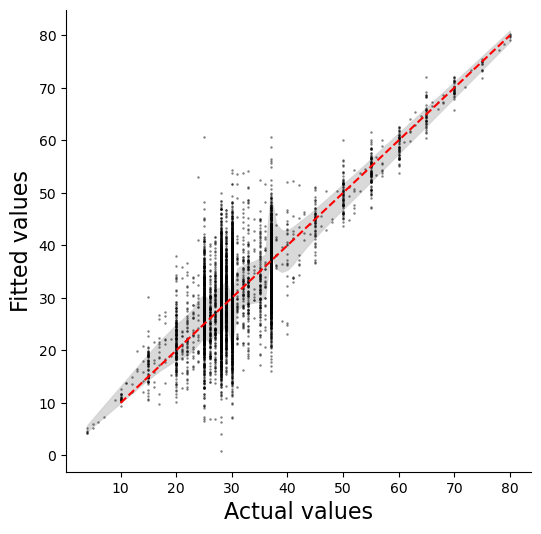

In [11]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=y, y=y_pred, ax=ax, linewidth=0, alpha=0.5, s=3, color='k')

ax.set_ylabel('Fitted values', fontsize=16)
ax.set_xlabel('Actual values', fontsize=16)

# get cis
pred_scaled = model.get_prediction(X)
pred_summary = pred_scaled.summary_frame(alpha=0.05)  # 95% CI

# upper and lower
ci_lower = pred_summary['mean_ci_lower'].values
ci_upper = pred_summary['mean_ci_upper'].values

# make a df
ci_df = pd.DataFrame({
    'y': y,         # your original x-axis variable
    'pred': y_pred,           # predicted y
    'lower': ci_lower,      # lower CI
    'upper': ci_upper       # upper CI
}).sort_values('y')

# smooth w/ loess
smoothed_lower = lowess(ci_df['lower'], ci_df['y'], frac=0.1, return_sorted=False)
smoothed_upper = lowess(ci_df['upper'], ci_df['y'], frac=0.1, return_sorted=False)

# fill
plt.fill_between(ci_df['y'], smoothed_lower, smoothed_upper, color='lightgray', label='95% CI (smooth)', alpha=0.85, zorder=0)

plt.plot((10, 80), (10, 80), linestyle='--', color='r')

sns.despine()
plt.savefig('./../data/figures/20251009_esmc_model.png', dpi=400, bbox_inches='tight')

In [12]:
model_coefficients = pd.Series(data=model.params.values,
                               index=X.columns)
print(model_coefficients.shape)

model_intervals = model.conf_int().rename(columns={0:'lower', 1:'upper'})
model_intervals['not_zero'] = model_intervals.apply(lambda row: not (row['lower'] <= 0 <= row['upper']), axis=1)

print(model_intervals.shape)

(960,)
(960, 3)


## Plot 2: coefficients

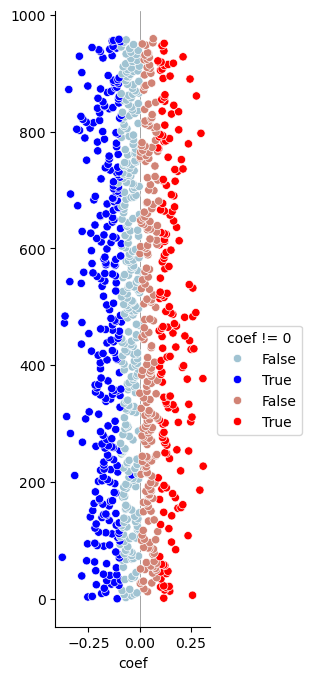

In [13]:
fig, ax = plt.subplots(figsize=(2, 8))
n = 29

plotdf = pd.DataFrame(model_coefficients.copy())

# plotdf["category"] = plotdf.index.map(
#     lambda f: feature_map[f]['category']
# )
# plotdf = plotdf.sort_values('category')

hues=model_intervals['not_zero'].loc[plotdf.index]

sns.scatterplot(x=plotdf.mask(plotdf[0] > 0)[0], 
                y=pd.Series(index=plotdf.index,
                            data=range(len(plotdf))),
               hue=hues, 
                palette=[sns.desaturate('skyblue', 0.5), 'blue'],
               zorder=2)

sns.scatterplot(x=plotdf.mask(plotdf[0] < 0)[0], 
                y=pd.Series(index=plotdf.index,
                            data=range(len(plotdf))),
               hue=hues, 
                palette=[sns.desaturate('tomato', 0.5), 'red'],
               zorder=2)

# x = model_intervals.reindex(plotdf.index).iloc[:, :2].values
# y = [[i]*2 for i in range(n)]
# for _x, _y in zip(x, y):
#     plt.plot(_x, _y, zorder=1, color='gray')

# ax.set_xticks([-10, 0, 10])
# ax.set_xlim(-12, 12)

ax.axvline(0, color='gray', zorder=0, linewidth=0.5)

sns.despine()
ax.set_ylabel('')
ax.set_xlabel('coef')

# ## Plot category labels

# # Collapse plotting by category groups
# categories = plotdf["category"]
# y_positions = range(len(plotdf))

# # Find start and end indices for each category
# group_ranges = defaultdict(list)
# for i, cat in enumerate(categories):
#     group_ranges[cat].append(i)

# # Clear default ticks
# ax.set_yticks(list(range(len(plotdf.index))))
# ax.set_yticklabels(plotdf.index)

# # Add category labels + brackets
# for cat, idxs in group_ranges.items():
#     start, end = min(idxs), max(idxs)
#     mid = (start + end) / 2

#     # Place category label at midpoint
#     ax.text(
#         1.15, mid, cat, va="center", ha="left",
#         transform=ax.get_yaxis_transform(), fontsize=9
#     )

#     # Draw a bracket line spanning the group
#     ax.plot(
#         [1.1, 1.1], [start, end], transform=ax.get_yaxis_transform(),
#         color="black", linewidth=1, clip_on=False
#     )

# # Legend
# ax.get_legend().remove()
handles, labels = ax.get_legend_handles_labels()
lgd = ax.legend(handles, labels, title='coef != 0', loc='upper left', bbox_to_anchor=(1, 0.5))

# plt.savefig('./../data/figures/20250630_coefficients.png', dpi=400, bbox_inches='tight')

# Perturbation test

In [225]:
baseline_score = r2_score(y, y_pred, sample_weight=weights)

rep_importances = []
for rep in range(1):
    importances = {}
    for i, col in enumerate(X.columns):
        display(i)
        clear_output(wait=True)
        X_perm = X.copy()
        X_perm[col] = np.random.permutation(X_perm[col].values)
        y_pred_perm = model.get_prediction(X_perm).predicted_mean
        perm_score = r2_score(y, y_pred_perm, sample_weight=weights)
        importances[col] = baseline_score - perm_score
    
    importances_df = pd.DataFrame.from_dict(importances, orient='index', columns=[f'importance_{rep}'])
    rep_importances.append(importances_df)

959

<Axes: xlabel='None', ylabel='None'>

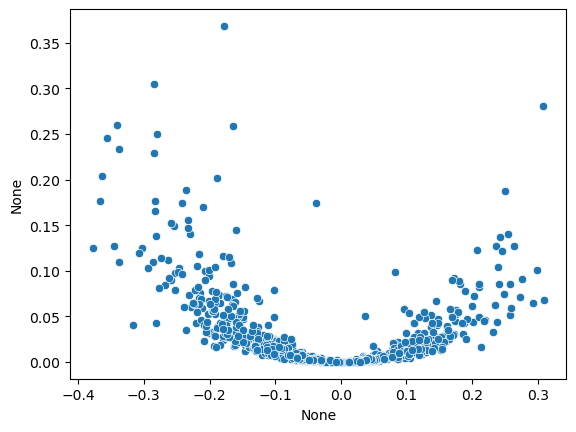

In [226]:
sns.scatterplot(y=pd.concat(rep_importances).mean(1), x=model_coefficients)

# Clustering

<Figure size 600x600 with 0 Axes>

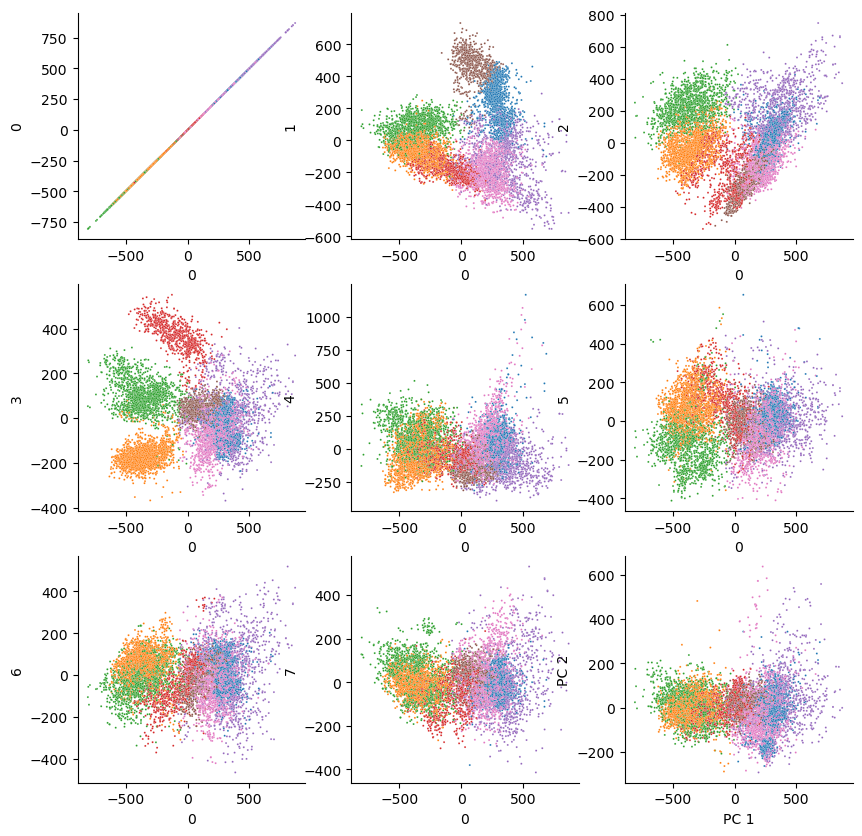

In [264]:
pca = PCA(n_components=5)
embeddings_reduced = pca.fit_transform(stacked_mean_embeddings)

kmeans = KMeans(n_clusters=7, random_state=42, n_init=10)
clusters = pd.Series(data=kmeans.fit_predict(embeddings_reduced),
                     index=[i.split('|')[1] for i in stacked_mean_embeddings.index])

# plot the clusters
plt.figure(figsize=(6, 6))
fig = plt.figure(figsize=(10, 10))
i = 1
for col1, col2 in itertools.product(plotdf.drop('temp', axis=1).columns, 
                                    plotdf.drop('temp', axis=1).columns):
    ax = fig.add_subplot(3,3,i)
    sns.scatterplot(
        data=plotdf.sort_values('temp'),
        x=col1,
        y=col2,
        hue=clusters,
        palette='tab10',
        s=2
    )
    i += 1
    ax.get_legend().remove()
    sns.despine()

    if i > 9:
        break

# plt.title(
#     f"PCA of mean embeddings at layer {layer_idx}.\nRand index: {rand_index:.2f}"
# )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

# visualization against structural features

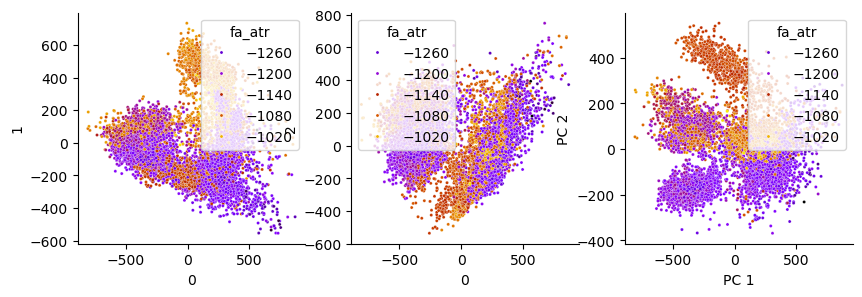

In [256]:

# plot the clusters
fig = plt.figure(figsize=(10, 3))
i = 1
for col1, col2 in itertools.product([0], 
                                    [1,2,3]):
    ax = fig.add_subplot(1,3,i)
    sns.scatterplot(
        data=plotdf.sort_values('temp'),
        x=col1,
        y=col2,
        hue=filtered.set_index('uid')['fa_atr'],
        palette='gnuplot',
        s=5
    )
    i += 1
    # ax.get_legend().remove()
    sns.despine()

    if i > 9:
        break

# plt.title(
#     f"PCA of mean embeddings at layer {layer_idx}.\nRand index: {rand_index:.2f}"
# )

plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.show()

## Redoing validations

## Mycobacteria

In [26]:
myco_md = pd.read_excel('./../data/validation_datasets/Mycobacteria/md/MycoGrowthOptima_IsolateInformation-Detailed_Supplementary_Table1_vFinal_072025.xlsx')

sra_table = pd.read_csv('./../data/validation_datasets/Mycobacteria/md/myco_SraRunTable.csv')
myco_md_full = pd.merge(sra_table[['Sample Name', 'Run']].assign(sample=sra_table['Sample Name'].apply(lambda x: x.replace('NTM', 'NTM-'))),
         myco_md,
         left_on='sample',
         right_on='Isolate ID')

myco_y = myco_md_full.set_index('Run')['Temperature Optimum (℃)']
myco_y

Run
SRR32180441    31.6
SRR32180442    38.2
SRR32180443    37.4
SRR32180444    32.8
SRR32180445    32.0
SRR32180446    37.9
SRR32180447    33.4
SRR32180448    38.6
SRR32180449    26.9
SRR32180450    23.9
SRR32180451    36.8
SRR32180452    20.7
SRR32180453    31.3
SRR32180454    43.0
SRR32180455    43.0
SRR32180456    30.8
SRR32180457    37.1
SRR32180458    30.5
SRR32180459    38.2
SRR32180460    32.8
Name: Temperature Optimum (℃), dtype: float64

In [16]:
with open('./../data/validation_datasets/Mycobacteria/adks.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

names = [r.id.split('|')[2].split('_hmm')[0] for r in records]
seqs = [str(r.seq) for r in records]

In [35]:
%%time
outputs = dict((n, o) for n,o in zip(names, batch_embed(esmc_model, seqs)))

with open(f'./../data/esmc/validation_data/myco/myco_embedding.pkl', 'wb') as handle:
    pickle.dump(outputs, handle)

CPU times: user 2min 12s, sys: 13.4 s, total: 2min 25s
Wall time: 9.74 s


In [36]:
myco_embed = load_mean_embeddings('./../data/esmc/validation_data/myco')
myco_inputs = get_layer_df(29, myco_embed)
myco_pred = model.predict(myco_inputs)

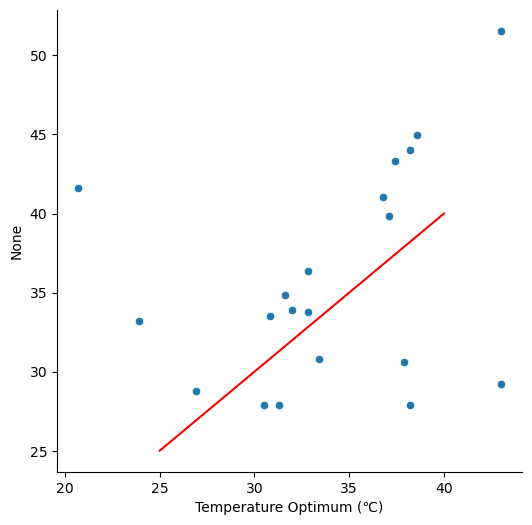

In [37]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=myco_y, y=myco_pred)
sns.despine()
plt.plot((25, 40), (25, 40), color='r')

## Arthrobacteria

In [52]:
arth_md = pd.read_csv('./../data/validation_datasets/Arthrobacter/md/2025_07_15-TOPT_Genomes.csv')
arth_y = arth_md.assign(id=arth_md['Genome_ID'].apply(lambda x: x.split('.fasta')[0])).set_index('id')['Topt']

In [66]:
with open('./../data/validation_datasets/Arthrobacter/adks.faa', 'r') as handle:
    records = [r for r in SeqIO.parse(handle, format='fasta')]

names = [r.id.split('|')[1].split('_hmm')[0] for r in records]
seqs = [str(r.seq) for r in records]

In [70]:
%%time
outputs = dict((n, o) for n,o in zip(names, batch_embed(esmc_model, seqs)))

with open(f'./../data/esmc/validation_data/arthrobacteria/arthrobacteria_embedding.pkl', 'wb') as handle:
    pickle.dump(outputs, handle)

CPU times: user 2min 18s, sys: 7.74 s, total: 2min 26s
Wall time: 7.17 s


In [71]:
outputs

{'8HZ65L_1_ASP410-2': ESMProteinError(error_code=500, error_msg='The size of tensor a (193) must match the size of tensor b (192) at non-singleton dimension 1'),
 '8HZ65L_3_24664': ESMProteinError(error_code=500, error_msg='The size of tensor a (194) must match the size of tensor b (193) at non-singleton dimension 1'),
 'barcode01_consensus': ESMProteinError(error_code=500, error_msg='The size of tensor a (193) must match the size of tensor b (192) at non-singleton dimension 1'),
 'barcode02_consensus': ESMProteinError(error_code=500, error_msg='The size of tensor a (193) must match the size of tensor b (192) at non-singleton dimension 1'),
 'barcode03_consensus': ESMProteinError(error_code=500, error_msg='The size of tensor a (194) must match the size of tensor b (193) at non-singleton dimension 1'),
 'barcode04_consensus': ESMProteinError(error_code=500, error_msg='The size of tensor a (194) must match the size of tensor b (193) at non-singleton dimension 1'),
 'barcode05_consensus':

In [64]:
arth_embed = load_mean_embeddings('./../data/esmc/validation_data/arthrobacteria')
arth_inputs = get_layer_df(29, arth_embed)
arth_pred = model.predict(arth_inputs)

In [65]:
arth_y

id
barcode29_consensus    16
barcode36_consensus    17
barcode03_consensus    18
barcode38_consensus    16
barcode48_consensus    17
barcode09_consensus    17
barcode39_consensus    16
barcode43_consensus    17
barcode33_consensus    14
barcode24_consensus    14
barcode35_consensus    17
barcode25_consensus    24
barcode11_consensus    18
barcode10_consensus    20
barcode52_consensus    16
barcode30_consensus    17
barcode22_consensus    17
barcode41_consensus    17
8HZ65L_1_ASP410-2      16
barcode46_consensus    19
barcode13_consensus    14
barcode40_consensus    17
barcode01_consensus    15
barcode08_consensus    18
barcode02_consensus    17
barcode37_consensus    17
barcode19_consensus    12
barcode12_consensus    16
barcode21_consensus    24
barcode14_consensus    24
barcode44_consensus    32
barcode20_consensus    18
8HZ65L_3_24664         27
barcode50_consensus    25
barcode42_consensus    24
barcode05_consensus    25
barcode32_consensus    23
barcode47_consensus    32
barcode04

In [57]:
arth_pred

barcode10_consensus_hmmsearch.tbl    29.869475
barcode12_consensus_hmmsearch.tbl    21.324882
barcode20_consensus_hmmsearch.tbl    23.287765
barcode24_consensus_hmmsearch.tbl    17.954755
barcode25_consensus_hmmsearch.tbl    29.869475
barcode29_consensus_hmmsearch.tbl    25.660098
barcode43_consensus_hmmsearch.tbl    21.672242
barcode44_consensus_hmmsearch.tbl    26.245610
DS72QC_1_ASP_418-1_hmmsearch.tbl     20.449625
dtype: float64

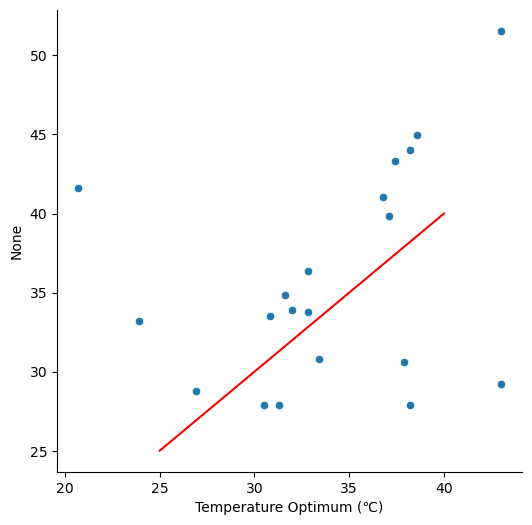

In [37]:
fig, ax = plt.subplots(figsize=(6,6))
sns.scatterplot(x=myco_y, y=myco_pred)
sns.despine()
plt.plot((25, 40), (25, 40), color='r')